In [ ]:
import tensorflow as tf
# print(tf.__version__)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# load dataset
dataset=pd.read_csv("Churn_Modelling.csv")
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# divide dataset into features and target
X=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]
# X.head()

In [ ]:
# Encoding the data(handle cat columns)
geography=pd.get_dummies(X['Geography'],drop_first=True)
gender=pd.get_dummies(X['Gender'],drop_first=True)
# X.head()

In [ ]:
# delete earlier cat columns and add new encoded columns
X=X.drop(['Geography','Gender'],axis=1)
# X
X=pd.concat([X,geography,gender],axis=1)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [ ]:
# split the data into train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)


In [ ]:
# feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
# now create ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [ ]:
# add input layer
classifier=Sequential()
classifier.add(Dense(units=11,activation='relu'))
# dropout layer
classifier.add(Dropout(0.3))
# add hidden layer
classifier.add(Dense(units=16,activation='relu'))
classifier.add(Dropout(0.2))
# add output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [ ]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [ ]:
early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                              min_delta=0.01,
                              patience=10,
                              verbose=1,
                              restore_best_weights=True,
                              mode='auto')


In [ ]:
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=100,callbacks=early_stopping)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7595 - loss: 0.5447 - val_accuracy: 0.7978 - val_loss: 0.4610
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8007 - loss: 0.4622 - val_accuracy: 0.8058 - val_loss: 0.4331
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8136 - loss: 0.4406 - val_accuracy: 0.8171 - val_loss: 0.4188
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8203 - loss: 0.4314 - val_accuracy: 0.8251 - val_loss: 0.4051
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8285 - loss: 0.4152 - val_accuracy: 0.8334 - val_loss: 0.3941
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8309 - loss: 0.4138 - val_accuracy: 0.8315 - val_loss: 0.3915
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8285 - loss: 0.4077 - val_accuracy: 0.8342 - val_loss: 0.3849
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8377 - loss: 0.3965 - val_accu

In [ ]:
# predict and evaluate test set results
y_pred=classifier.predict(X_test)
y_pred=(y_pred>=0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
# make confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[1563,   32],
       [ 250,  155]])

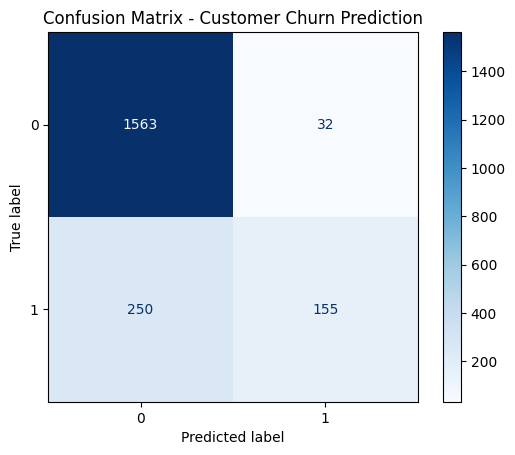

In [ ]:
# visualize confusion matrix using direct confusion matrix not seaborn
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Blues"
)
plt.title("Confusion Matrix - Customer Churn Prediction")
plt.show()

In [ ]:
# calculate the accurace
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)
score

0.859

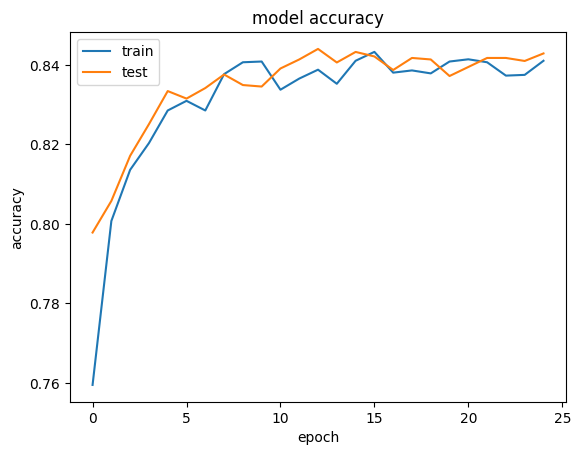

In [ ]:
# summarize history from model
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'],loc='upper left')
plt.title('model accuracy')
plt.show()

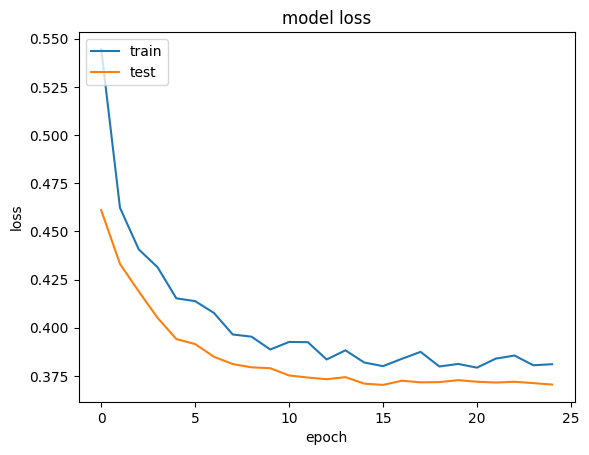

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('model loss')
plt.legend(['train','test'],loc='upper left')
plt.show()